In [15]:
data = [
    # -------------------------------
    # Cosmological Model Dependent
    # -------------------------------
    {"group": "model", "label": "CMB (Planck)",  "H0": 67.4, "err": 0.5, "color": "forestgreen"},
    {"group": "model", "label": "CMB (WMAP + ACT)","H0": 67.6, "err": 1.1, "color": "green"},
    {"group": "model", "label": "CMB (WMAP + SPT)","H0": 68.2, "err": 1.1, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.52, "err": 0.62, "color": "green"},
    {"group": "model", "label": "DESI-DR1 BAO + CMB","H0": 67.97, "err": 0.38, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + BBN + " + r'${\theta}_{\star}$',"H0": 68.45, "err": 0.47, "color": "green"},
    {"group": "model", "label": "DESI-DR2 BAO + CMB","H0": 68.17, "err": 0.28, "color": "green"},


    # -------------------------------
    # Direct (D vs z)
    # -------------------------------
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.04, "err": 1.04, "color": "red"},
    {"group": "direct", "label": r"SN Ia - Cepheids (CCHP/JWST)","H0": 72.05, "err": 1.86, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/HST)","H0": 73.40, "err": 2.10, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - Cepheids (S$H_0$ES/JWST)","H0": 73.20, "err": 0.90, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/HST)","H0": 69.80, "err": 0.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (Anand et al./HST)","H0": 71.50, "err": 1.80, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - TRGB (CCHP/JWST)","H0": 69.85, "err": 1.75, "color": "salmon"},
    {"group": "direct", "label": r"SN Ia - JAGB (CCHP/JWST)","H0": 67.96, "err": 1.85, "color": "salmon"},

]

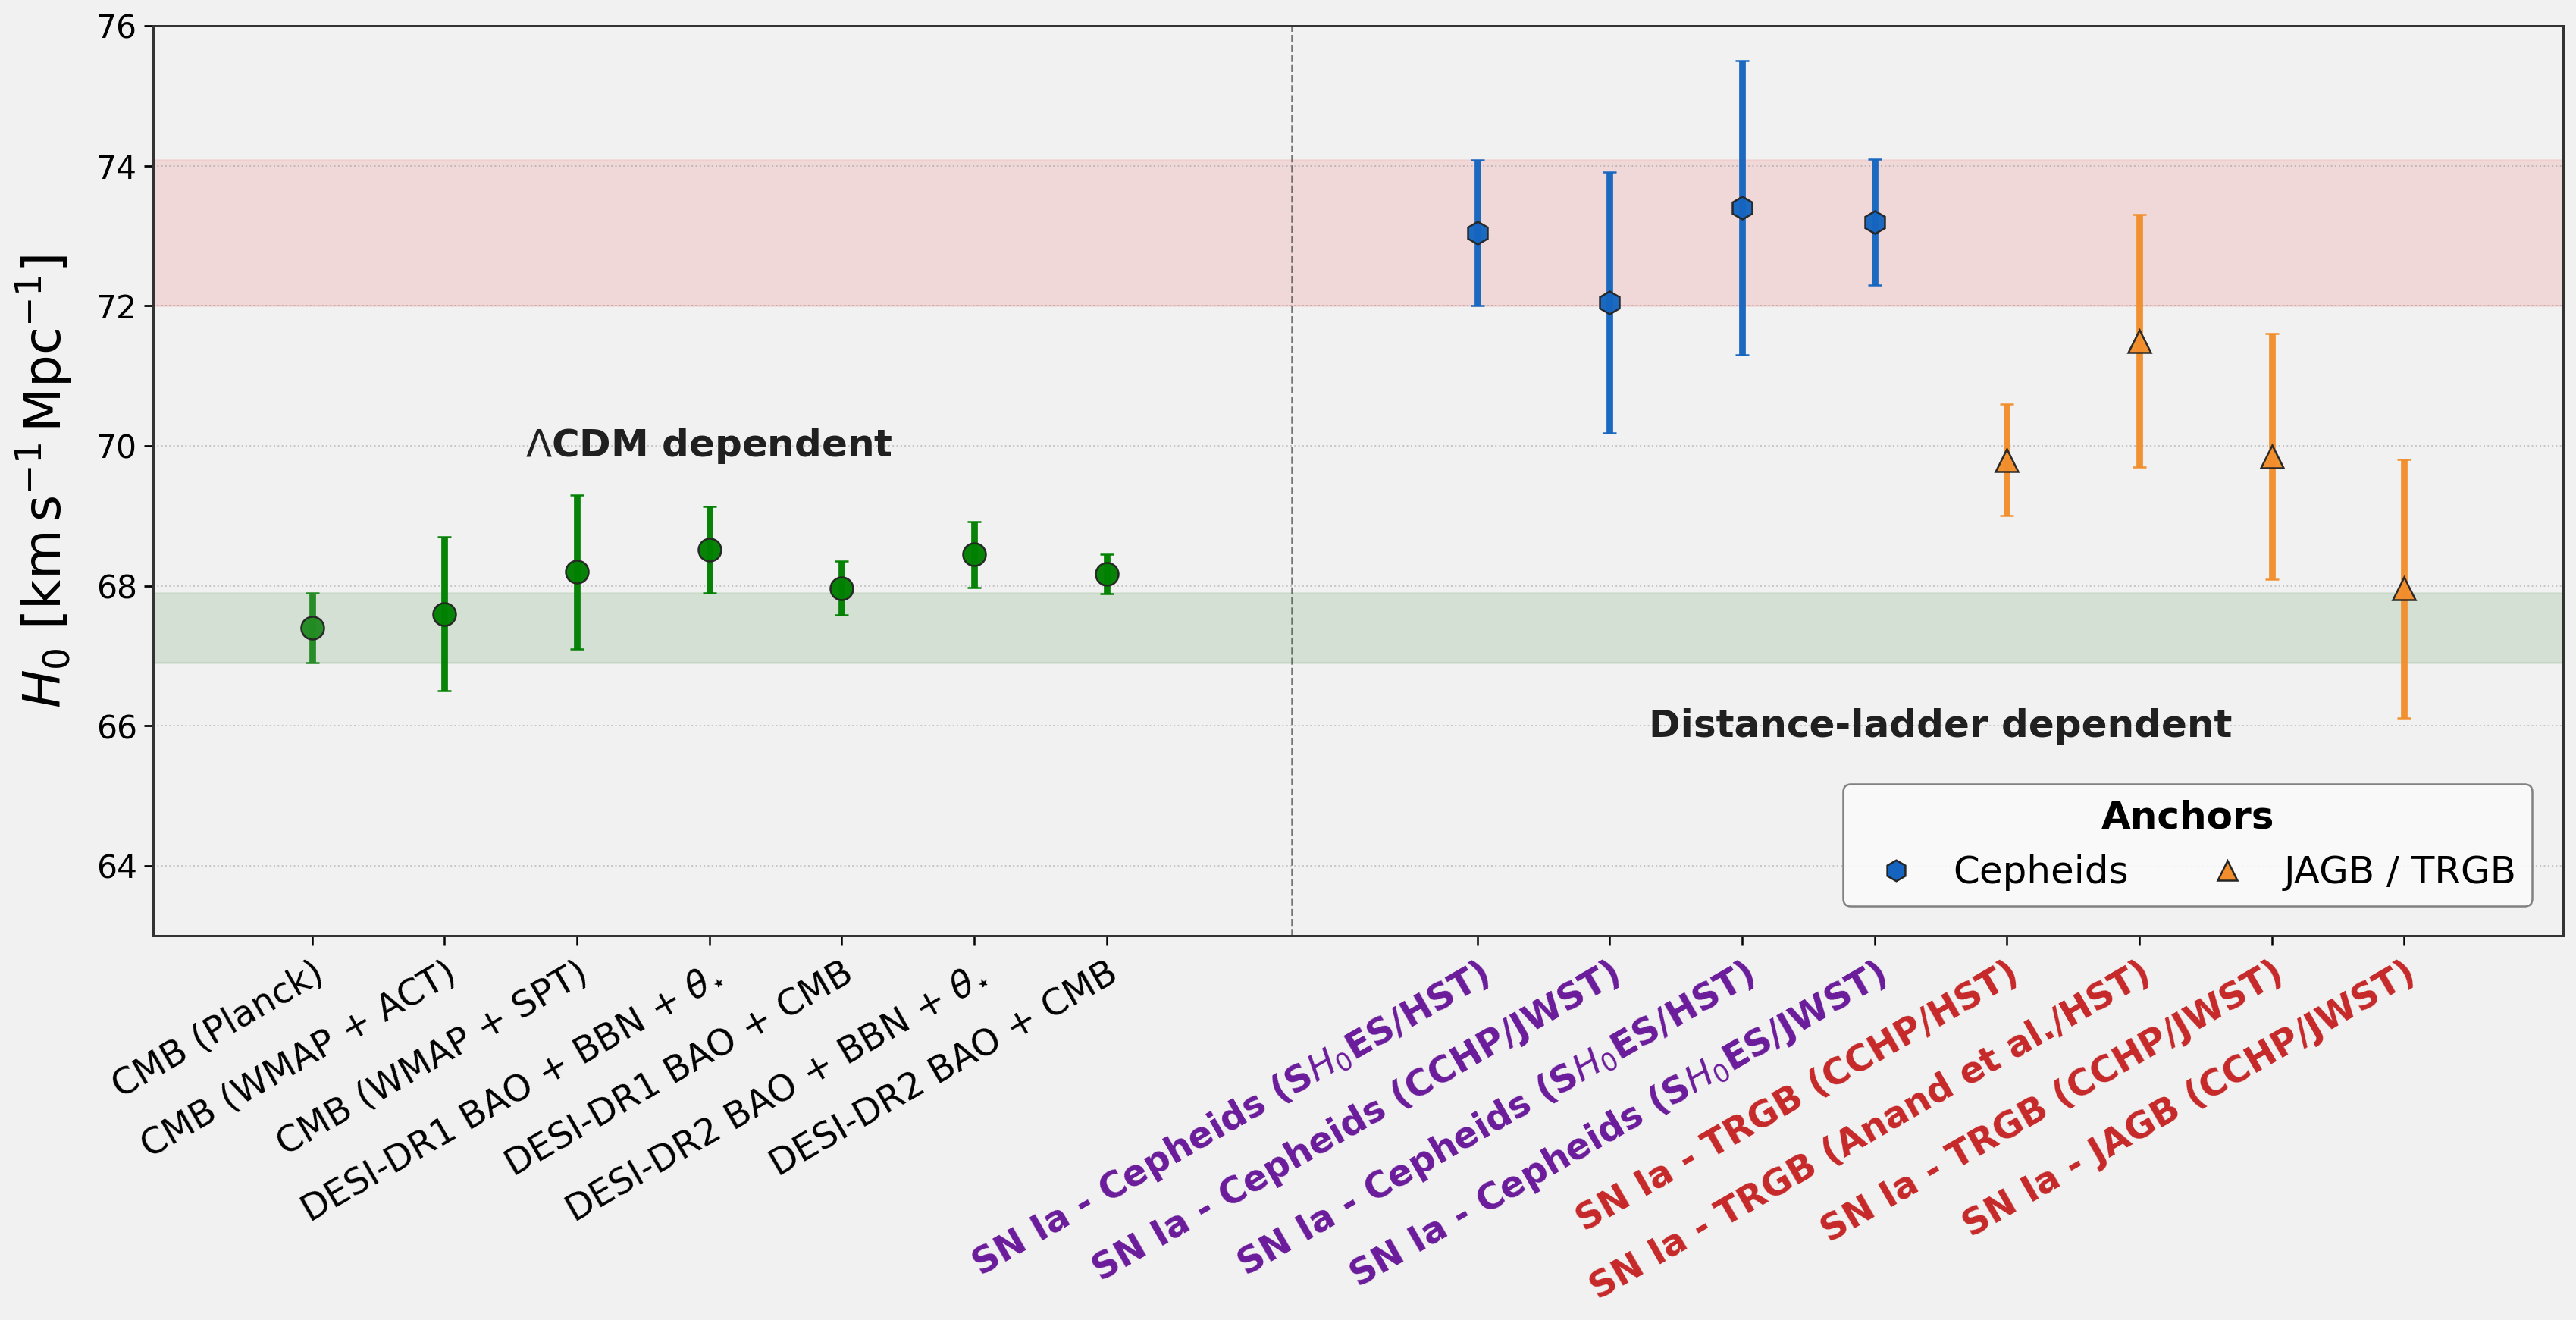

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ============================================================
# Clasificación visual
# ============================================================

def visual_style(label, original_color):
    """
    Retorna:
        marker, point_color, label_color, label_weight
    """
    label_upper = label.upper()

    if "TRGB" in label_upper or "JAGB" in label_upper:
        return "^", "#F28E2B", "#C62828", "bold"

    if "CEPHEID" in label_upper or "CEPH." in label_upper:
        return "h", "#1565C0", "#6A1B9A", "bold"

    return "o", original_color, "black", "normal"


# ============================================================
# Posiciones en x con espacios entre grupos
# ============================================================

gap = 1.8

x_positions = []
labels = []

group_positions = {
    "model": [],
    "direct": [],
}

separator_positions = []

current_x = 0
prev_group = data[0]["group"]

for i, d in enumerate(data):

    if i > 0 and d["group"] != prev_group:
        separator_positions.append(current_x - 0.5 + gap / 2)
        current_x += gap
        prev_group = d["group"]

    x_positions.append(current_x)
    labels.append(d["label"])
    group_positions[d["group"]].append(current_x)

    current_x += 1


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(19.3, 10.584), dpi=180)

bg = "#F1F1F1"

fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)


# ============================================================
# Bandas de referencia
# ============================================================

# Planck
ax.axhspan(
    66.9, 67.9,
    color="#66A061",
    alpha=0.20,
    zorder=0
)

# SH0ES
ax.axhspan(
    72.0, 74.08,
    color="#EF6A6A",
    alpha=0.18,
    zorder=0
)


# ============================================================
# Rejilla horizontal
# ============================================================

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.8,
    color="#777777",
    alpha=0.35,
    zorder=0
)


# ============================================================
# Separadores verticales
# ============================================================

for sep in separator_positions:
    ax.axvline(
        sep,
        color="#333333",
        linestyle="--",
        linewidth=1.0,
        alpha=0.65,
        zorder=1
    )


# ============================================================
# Puntos y barras de error
# ============================================================

for x, d in zip(x_positions, data):

    marker, point_color, _, _ = visual_style(
        d["label"],
        d["color"]
    )

    ax.errorbar(
        x,
        d["H0"],
        yerr=d["err"],
        fmt=marker,
        markersize=12,
        markerfacecolor=point_color,
        markeredgecolor="#252525",
        markeredgewidth=1.0,
        color=point_color,
        ecolor=point_color,
        elinewidth=3.5,
        capsize=3.5,
        capthick=3.5,
        alpha=0.97,
        zorder=3
    )


# ============================================================
# Ejes
# ============================================================

ax.set_xlim(
    min(x_positions) - 1.2,
    max(x_positions) + 1.2
)

ax.set_ylim(63, 70)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    labels,
    rotation=30,
    ha="right",
    rotation_mode="anchor",
    fontsize=19
)

# Dar formato individual a cada etiqueta
for tick_label, d in zip(ax.get_xticklabels(), data):

    _, _, text_color, text_weight = visual_style(
        d["label"],
        d["color"]
    )

    tick_label.set_color(text_color)
    tick_label.set_fontweight(text_weight)

ax.set_yticks(np.arange(64, 77, 2))

ax.tick_params(
    axis="y",
    labelsize=17,
    width=1.1,
    length=5
)

ax.tick_params(
    axis="x",
    width=1.0,
    length=5,
    pad=5
)

ax.set_ylabel(
    r"$H_0\ [\mathrm{km\,s^{-1}\,Mpc^{-1}}]$",
    fontsize=27,
    fontweight="bold",
    labelpad=12
)


# ============================================================
# Títulos de los grupos
# ============================================================

#group_title_y = 76
#group_title_size = 20

group_titles = {
    "model": r"$\Lambda$CDM dependent",
    "direct": "Distance-ladder dependent",
}


ax.text(
    np.mean(group_positions["model"]),
    70,
    group_titles["model"],
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#202020"
)

ax.text(
    np.mean(group_positions["direct"]),
    66,
    group_titles["direct"],
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#202020"
)



# ============================================================
# Leyenda de símbolos
# ============================================================

legend_elements = [
    #Line2D(
    #    [0], [0],
    #    marker="o",
    #    linestyle="none",
    #    markersize=9,
    #    markerfacecolor="#555555",
    #    markeredgecolor="#252525",
    #    label="No-ladder"
    #),
    Line2D(
        [0], [0],
        marker="h",
        linestyle="none",
        markersize=11,
        markerfacecolor="#1565C0",
        markeredgecolor="#252525",
        label="Cepheids"
    ),
    Line2D(
    [0], [0],
    marker="^",
    linestyle="none",
    markersize=10.5,
    markerfacecolor="#F28E2B",
    markeredgecolor="#252525",
    label="JAGB / TRGB"
    ),
]


legend = ax.legend(
    title="Anchors", 
    handles=legend_elements, 
    loc="lower right", 
    bbox_to_anchor=(0.995, 0.012), 
    ncol=3, 
    fontsize=20, 
    frameon=True, 
    framealpha=0.92, 
    edgecolor="#777777", 
    columnspacing=1.6, 
    handletextpad=0.5,
    title_fontproperties={'size': 20, 'weight': 'bold'} 
)

legend.get_frame().set_facecolor("#FAFAFA")


# ============================================================
# Bordes
# ============================================================

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("#333333")


# Espacio para etiquetas inclinadas y ecuaciones superiores
plt.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.94,
    bottom=0.31
)

plt.savefig(
    "CFH_HubbleTension.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
    #facecolor=fig.get_facecolor()
)

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

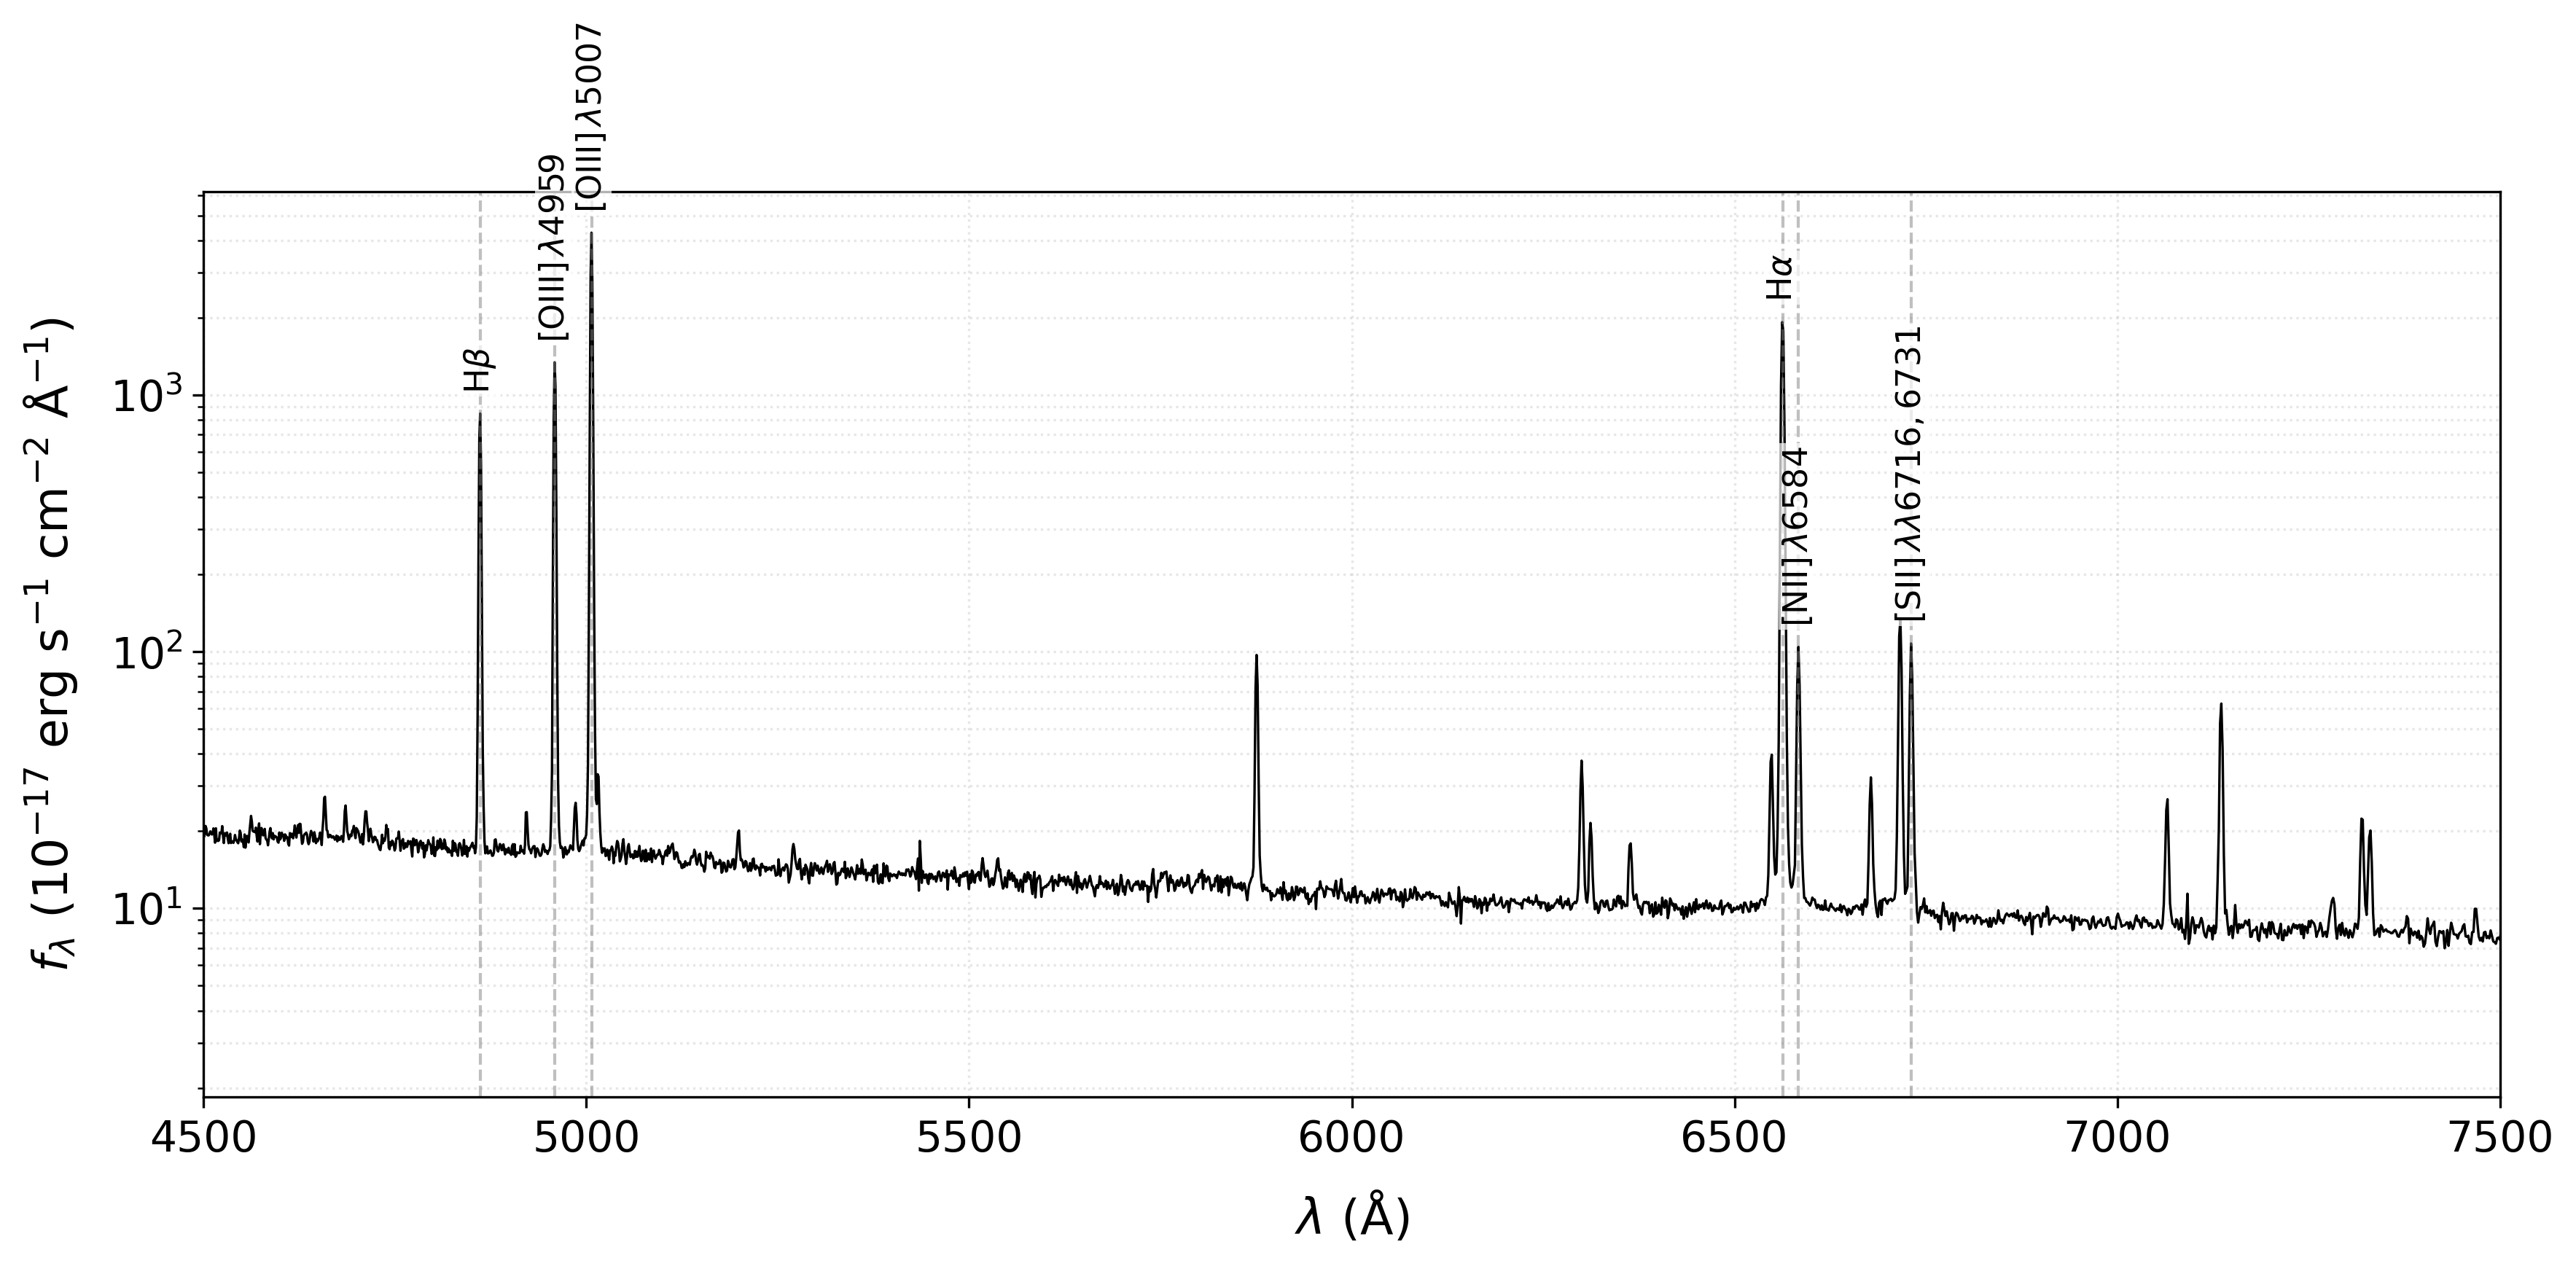

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# 1. Configuración de estilo tipo LaTeX para póster científico
plt.rcParams.update({
    "text.usetex": False,            # Habilita el renderizado de LaTeX
    "font.family": "serif",         # Tipografía con serifas clásica de LaTeX
    "font.serif": ["Computer Modern"], 
    "axes.labelsize": 16,           # Tamaño de etiquetas de los ejes
    "font.size": 14,                # Tamaño de fuente general
    "legend.fontsize": 12,          # Tamaño de la leyenda
    "xtick.labelsize": 14,          # Tamaño de números en el eje X
    "ytick.labelsize": 14,          # Tamaño de números en el eje Y
    "figure.titlesize": 18          # Tamaño del título principal
})

# 2. Cargar el archivo FITS de SDSS DR7
# Reemplaza 'espectro_dr7.fits' con la ruta de tu archivo descargado
fits_filename = 'spSpec-51910-0275-445.fit'

with fits.open(fits_filename) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    zz = hdul[0].header['Z']
    # En SDSS DR7, los datos suelen extraerse de la tabla de la extensión 1
    # La longitud de onda está guardada en escala logarítmica base 10 (loglam)
    flux = data[0]
    wav00 = hdul[0].header['COEFF0']
    wavdiff = hdul[0].header['COEFF1']

    waveair = 10**(wav00 + wavdiff*np.arange(len(flux)))

    wavelength = waveair/(1.0+2.735182E-4+131.4182/(waveair)**2 +2.76249E8/(waveair)**4)
    wavelength = wavelength/(1.0+zz)
# 3. Definición de las líneas de emisión clave (Galaxia HII)
# Longitudes de onda en el aire (vacío/aire estándar)
lineas_emision = {
    r'$\mathrm{H}\beta$': 4861.3,
    r'$[\mathrm{OIII}]\,\lambda 4959$': 4958.9,
    r'$[\mathrm{OIII}]\,\lambda 5007$': 5006.8,
    r'$\mathrm{H}\alpha$': 6562.8,
    r'$[\mathrm{NII}]\,\lambda 6584$': 6583.4,
    r'$[\mathrm{SII}]\,\lambda\lambda 6716,6731$': 6731.0  # Promedio visual para el doblete
}

# 4. Crear la gráfica
fig, ax = plt.subplots(figsize=(12, 6), dpi=300) # Alta resolución para póster

# Graficar el espectro de la galaxia
ax.plot(wavelength, flux, color='black', lw=0.8, label='Espectro Observado')

# Configurar el rango del eje X (4000 a 8000 Angstroms)
ax.set_xlim(4500, 7500)

# Configurar el eje Y en escala logarítmica
ax.set_yscale('log')

# Etiquetas de los ejes usando formato matemático de LaTeX
ax.set_xlabel(r'$\lambda$ (Å)', labelpad=10)
ax.set_ylabel(r'$f_\lambda$ ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)', labelpad=10)
#ax.set_title(r'Espectro de Galaxia $\mathrm{H\,II}$ -- SDSS DR7', pad=15)

# 5. Señalar de forma automática las líneas de emisión
# Filtramos el flujo en el rango visible para ajustar la altura del texto
mask = (wavelength >= 4000) & (wavelength <= 8000)
max_flux = np.max(flux[mask])

for nombre, wl in lineas_emision.items():
    # Dibujar una línea vertical discontinua gris en la posición de la línea
    ax.axvline(x=wl, color='gray', linestyle='--', alpha=0.5, lw=1)
    
    # Buscar el flujo local aproximado para posicionar bien la etiqueta de texto
    idx_cercano = np.abs(wavelength - wl).argmin()
    flujo_linea = flux[idx_cercano]
    
    # Desplazar el texto ligeramente hacia arriba del pico de la línea
    # Si el eje es logarítmico, multiplicamos para mantener una proporción visual
    pos_y = flujo_linea * 1.2 if flujo_linea > 0 else max_flux * 0.5
    
    # Evitar que el texto se salga por arriba de la gráfica
    if pos_y > max_flux * 2:
        pos_y = max_flux * 1.1

    ax.text(wl, pos_y, nombre, rotation=90, verticalalignment='bottom', 
            horizontalalignment='center', fontsize=11, 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Ajustes estéticos finales
ax.grid(True, which='both', linestyle=':', alpha=0.3)
#ax.legend(loc='upper right')
plt.tight_layout()

# Guardar la imagen optimizada para impresión de póster
plt.savefig('espectro_galaxia_hii.png', format='png', bbox_inches='tight', transparent=True, dpi=600)
plt.show()
